In [2]:
from datetime import datetime
import numpy as np
#import scipy.linalg.eigvals
import scipy.sparse.linalg
from scipy.spatial import ConvexHull
from scipy.optimize import minimize
#from tqdm import tqdm
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import networkx as nx
import networkx as nx
import numpy as np
import itertools
from math import *
import random
import scipy.optimize as opt
import sys
from scipy.optimize import check_grad
from itertools import chain
from collections import defaultdict
from matplotlib import rc

#from tqdm import tqdm

Transition position: 0.424


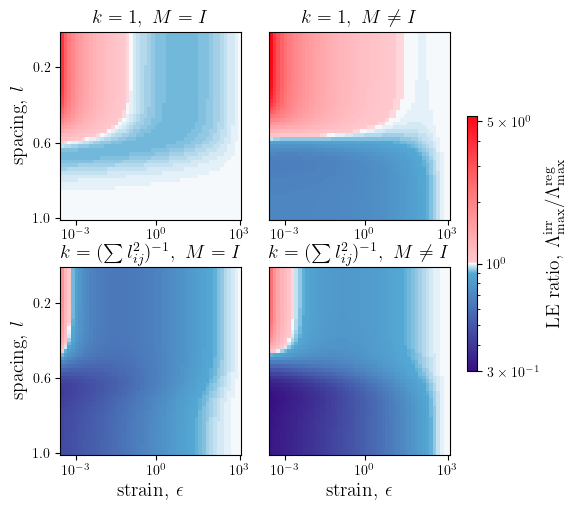

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm, LogNorm
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib import cm
from matplotlib.colors import Normalize
import numpy as np

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

def make_diverging_cmap_at_value(vmin, vmax, vcenter, n=1000):
    """
    Create a diverging colormap where the transition point is at vcenter 
    on a log scale between vmin and vmax, using seaborn crest → flare.
    """

    # Log positions
    log_min = np.log10(vmin)
    log_max = np.log10(vmax)
    log_center = np.log10(vcenter)

    center_frac = (log_center - log_min) / (log_max - log_min)
    print(f"Transition position: {center_frac:.3f}")

    # Number of samples per side
    n_left = int(n * center_frac)
    n_right = n - n_left

    # Seaborn colormaps
    # crest: dark blue → light greenish
    # flare: light peach → deep red
    left_colors = sns.color_palette("GnBu", n_left)
    #base = sns.color_palette("RdPu", int(n_right*1.25))
    #cut = int(0.125 * n_right*1.25)   # 12.5% trimmed from each side
    #right_colors = base[cut : int(n_right*1.25) - cut]
    right_colors = sns.color_palette("PuRd", n_right)
    # Convert to RGBA arrays
    left_colors = np.array(left_colors)
    right_colors = np.array(right_colors)

    combined = np.vstack([left_colors, right_colors])

    return LinearSegmentedColormap.from_list("crest_flare_log", combined)

datas = np.sqrt(np.load('data2.npy'))
plt.rcParams.update(plt.rcParamsDefault)
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)
# Compute global min and max
global_min = 0.3#np.min(datas)
global_max = np.max(datas)

# Create colormap with white at 1
cmap = make_diverging_cmap_at_value(global_min, global_max, vcenter=1.01)
cmap = LinearSegmentedColormap.from_list('my gradient', (
    # Edit this gradient at https://eltos.github.io/gradient/#0:391083-38.1:54A9D4-42.2:FFFFFF-42.4:FFCACF-72.4:FF7174-100:FF0716
    (0.000, (0.224, 0.063, 0.514)),
    (0.381, (0.329, 0.663, 0.831)),
    (0.422, (1.000, 1.000, 1.000)),
    (0.424, (1.000, 0.792, 0.812)),
    (0.724, (1.000, 0.443, 0.455)),
    (1.000, (1.000, 0.027, 0.086))))
#cmap = plt.cm.get_cmap('coolwarm')
# Use standard LogNorm
#shared_norm = LogNorm(vmin=global_min, vmax=global_max)

stretches = np.logspace(np.log10(3E-4), np.log10(1E3), 50)
y_values = np.arange(1, 51)/50
log_ticks = [1e-3, 1e0,  1e3]
tick_positions = [np.argmin(np.abs(stretches - t)) for t in log_ticks]
tick_labels = [f"$10^{{{int(np.log10(t))}}}$" for t in log_ticks]
labels = [r'$k=1,\ M \neq I$',
    r'$k=1,\ M = I$',
    
    r'$k=(\sum l_{ij}^2)^{-1},\ M \neq I$',
    r'$k=(\sum l_{ij}^2)^{-1},\ M = I$',
    
]
# Example setup
fig = plt.figure(figsize=(5.5, 5.5))  # better layout control
gs = gridspec.GridSpec(2, 2, figure=fig, wspace=0.15, hspace=0.25)
axes = [fig.add_subplot(gs[i, j]) for i in range(2) for j in range(2)]

ims = []

order=[1,0,3,2]
# Create a single shared norm
shared_norm = LogNorm(vmin=global_min, vmax=global_max)


for i, ax in enumerate(axes):
    data_mat = datas[order[i]]
    #norm = TwoSlopeNorm(vmin=np.min(data_mat), vcenter=1.0000001, vmax=np.max(data_mat))
    im = ax.imshow(data_mat, aspect='auto', cmap=cmap, norm=shared_norm, interpolation='nearest')
    ims.append(im)

    # Set ticks
    ax.set_xticks(tick_positions)
    
    ax.set_xticklabels(tick_labels)
    ytick_vals = [0.2, 0.6, 1.0]
    ytick_positions = [np.argmin(np.abs(y_values - v)) for v in ytick_vals]
    ax.set_yticks(ytick_positions)
    ax.set_yticklabels([f"{v:.1f}" for v in ytick_vals])

    # Labels and title
    ax.set_title(labels[order[i]],fontsize=14)
    if i == 2 or i == 3:
        ax.set_xlabel('strain, $\\epsilon$',fontsize=14)
    ax.set_ylabel('spacing, $l$',fontsize=14)

    # 🔹 Remove y labels/ticks for second column (j == 1)
    if i % 2 == 1:  # i = 1 or 3 → second column
        ax.set_ylabel('')
        ax.set_yticks([])
        ax.set_yticklabels([])

# Add a single colorbar for all subplots
# Using `pad` to avoid overlap, and `aspect=40` for slimmer bar
cbar = fig.colorbar(
    ims[-1],
    ax=axes,
    orientation='vertical',
    fraction=0.046,
    pad=0.04,
    aspect=25,
    shrink=0.6
)

cbar.set_ticks([0.3, 1e0, 5])
cbar.set_ticklabels([r'$3\times10^{-1}$', r'$10^{0}$', r'$5\times10^{0}$'])
#cbar.set_label("eigenvalue ratio",fontsize=14)
cbar.set_label('LE ratio, $\Lambda_{\mathrm{max}}^{\mathrm{irr}}/\Lambda_{\mathrm{max}}^\mathrm{{reg}}$',fontsize=14)

#cbar.ticklabel_format(useMathText=True)
#fig.tight_layout(pad=1.0, w_pad=0.5, h_pad=5)
#plt.tight_layout()
plt.savefig('./GEO_PAPER_FIGS/2D_heat_sq.svg',bbox_inches = "tight",transparent=True)
plt.show()


In [27]:
datas

array([[[5.25935915, 3.72741014, 3.05015341, ..., 0.99931165,
         0.99982213, 1.        ],
        [5.25845223, 3.72709389, 3.04998357, ..., 0.99931025,
         0.99982087, 1.        ],
        [5.25713342, 3.72663429, 3.04973721, ..., 0.99930954,
         0.99982027, 1.        ],
        ...,
        [0.69800208, 0.69807207, 0.69817816, ..., 0.98662542,
         0.99685823, 1.        ],
        [0.69833601, 0.69839895, 0.69849797, ..., 0.98661495,
         0.99685613, 1.        ],
        [0.69856682, 0.69862501, 0.69871897, ..., 0.98660775,
         0.99685469, 1.        ]],

       [[3.74506834, 2.66910122, 2.19662251, ..., 0.98044158,
         0.99008601, 1.00000005],
        [3.74465567, 2.6689592 , 2.19654734, ..., 0.98044133,
         0.99008517, 1.00000002],
        [3.74405563, 2.66875289, 2.1964383 , ..., 0.9804413 ,
         0.99008482, 1.00000001],
        ...,
        [0.99896357, 0.99898472, 0.99900583, ..., 0.99995767,
         0.99997884, 1.        ],
        [0.9

In [5]:
# constant k 1D
import networkx as nx
def disp(P):
    P = np.asarray(P)
    delta = P[:, None] - P[None, :]
    i, j = divmod(abs(delta).argmax(), len(P))
    
    if (i, j) in edges:
        delta[i, j] = -(X - abs(delta[i, j]))
        delta[j, i] = -delta[i, j]
    elif (j, i) in edges:
        delta[i, j] = X - abs(delta[i, j])
        delta[j, i] = -delta[i, j]
    
    return delta

def dist(P):
    P = np.asarray(P)
    delta = abs(P[:, None] - P[None, :])
    i, j = divmod(delta.argmax(), len(P))
    if (i, j) in edges or (j, i) in edges:
        delta[i, j] = delta[j, i] = X - delta[i, j]
    return np.abs(delta)

def dist_pair(u,v):
    return np.sqrt(((u[0]-v[0])-X*np.round((u[0]-v[0])/sz))**2)
                   


def inverse_M(graph):
    n = len(graph.nodes)
    A = nx.adjacency_matrix(graph).toarray()
    ls = Dist1 * A
    M = np.zeros((n, n))
    A = nx.adjacency_matrix(graph).toarray()
    #if mode == 'constant_k':
    rho = 2*n/np.sum(ls**2)
    M = rho * ls**2 / 6
    np.fill_diagonal(M, 2 * (np.sum(M, axis=1) - np.diag(M)))

    return np.linalg.inv(M)


def eig(g,mass_on_spring=False):
    L = nx.laplacian_matrix(g).toarray()
    if mass_on_spring:
        L = L * inverse_M(g)
    
    #print(L)
    if bound == 'periodic' or bound == 'free':
        lid = 1
    else:
        lid = 0
    
    eigenValues, eigenVectors = scipy.linalg.eig(L)
    idx = eigenValues.argsort()[::1]   
    eigenValues = eigenValues[idx]
    #print(L,eigenValues)
    eigenVectors = eigenVectors[:,idx]
    vec = eigenVectors[:,lid]
    K_eigs = sorted(np.real(eigenValues),reverse=False)
    #print(K_eigs)
    K_eig_min = K_eigs[lid]
    #L = L.astype(float)
    #K_eig_min,vec = scipy.sparse.linalg.eigs(L,k=lid+1,which='SR')
    return vec, np.real(K_eig_min)  

def update_pos(g0,mode='constant_a',mass_on_spring=False,unity_k=True,v_edges=None,tolerance=1E-16):  
    
    start_time = datetime.now()
    nodes = list(G.nodes())
    g = g0.copy()
    
    P00 = list(g.nodes())
    
    P1_old = np.array(list(nx.get_node_attributes(g,'pos').values()))
    
    A = nx.adjacency_matrix(g,nodelist = P00).toarray()
    
    n = sz
    
    if mode == 'constant_k':
        def k(P):
            if unity_k:
                return 1
            else: 
                return 2/np.sum(A*Dist1**2)
        def k_eff(P):
            D = dist(P)
            
            ks = k(P)*(D-Dist1)/(D)
            #print('sum',np.sum(A*Dist1**2))
            
            ks[np.isnan(ks)] = 0
            return ks
    
    if mode == 'constant_v':
        v_edge = 0.5*V_tot/sz**2
        def k(P):
            #P = P.reshape((-1, 2))
            D = dist(P)
            ks = v_edge*A/(Dist1**2)
            ks[np.isnan(ks)] = 0
            #print(ks)
            return ks
        def k_eff(P):
            #P = P.reshape((-1, 2))
            D = dist(P)
            ks = v_edge*A*((D-Dist1))/(D*Dist1**2)
            ks[np.isnan(ks)] = 0
            #ks[ks<0] = 0
            return ks
    
    elif mode == 'constant_a':
        def k(P):
            #P = P.reshape((-1, 2))
            D = dist(P)
            ks = 2*V_tot*Dist1/np.sum(A*Dist1)*A/(Dist1**2)
            ks[np.isnan(ks)] = 0
            return ks
        def k_eff(P):
            #P = P.reshape((-1, 2))
            D = dist(P)
            ks = 2*V_tot*Dist1/np.sum(A*Dist1)*A*((D-Dist1))/(D*Dist1**2)
            ks[np.isnan(ks)] = 0
            #ks[ks<0] = 0
            return ks
    
    elif mode == 'constant_l':
        v_edges_mat = np.zeros((n,n))
        for i in range(len(list(G.edges()))):
            edge = list(G.edges())[i]
            v_edges_mat[nodes.index(edge[0]),nodes.index(edge[1])] = v_edges[i]
            v_edges_mat[nodes.index(edge[1]),nodes.index(edge[0])] = v_edges[i]
        
        def k(P):
            #P = P.reshape((-1, 2))
            ks = v_edges_mat*A/(Dist1)
            ks[np.isnan(ks)] = 0
            return ks
        def k_eff(P):
            #P = P.reshape((-1, 2))
            D = dist(P)
            ks = v_edges_mat*A*((D-Dist1))/(D*Dist1)
            ks[np.isnan(ks)] = 0
            #ks[ks<0] = 0
            #print(A,ks)
            return ks
    
    def energy(P):
        D = dist(P)
        if mode == 'zero':
            return (.5 * (1 * A * D**2).sum())
        else:
            return (.5 * (A * k(P) *((D-Dist1))**2).sum())

    def minusforce(P):
        #P = P.reshape((-1, 2))
        D = disp(P)
        
        #D1 = disp(P1_old)
        minusdiffD = D-D1   #minusdiffdisp(P,P1_old,ratio=rest_ratio)
        Dist = dist(P)
        #Dist1 = dist(P1_old)
        #print(A*k(P)*minusdiffD)
        
        if mode == 'zero':
            return -2*np.sum(1*A*disp(P),axis=2).T.ravel()
        else:
            return np.sum(A*k(P)*minusdiffD,axis=2).T.ravel()

    

    optimized = opt.minimize(energy, np.array(P1_old).ravel(),
                      method="L-BFGS-B",tol=tolerance,options={"gtol":tolerance,'maxfun':1E8})
    P1 = optimized.x
    #print(optimized, max(abs(minusforce(P1))))
    displacement = np.sqrt(np.sum(np.square(P1 - P1_old)))
    max_displacement = np.max(displacement)
    print(P1)
    #print('global %s' % max_displacement)
    P1_dict = dict(zip(P00,P1))
    P1_old_dict = dict(zip(P00,P1_old))
    nx.set_node_attributes(g,P1_dict,'pos')
    
    
    #plt.figure(figsize=(6,6),constrained_layout=True)
              
    #nx.draw(g,node_size = 4,with_labels=True,pos = nx.get_node_attributes(g,'pos'))
    
    #plt.show()
    
    
    ks = k_eff(P1)
    print(stretch,ks)
    for u, v in g.edges():
        
        idx_u = nodes.index(u)
        idx_v = nodes.index(v)
        #print(u,v,idx_u,idx_v)
        edge_weight = ks[idx_u,idx_v]
        #print(edge_weight)
        g[u][v]['weight'] = edge_weight
        #print(edge_weight)
    
    vec,K_eig_min = eig(g,mass_on_spring)
    #print(minusforce(P1)[71])
    #print(K_eig_min)
    end_time = datetime.now()
    #print(f"⏱️ Duration: {end_time - start_time}")
    return g, K_eig_min



def analytical_alpha_const_a(g0,stretch,v_edges=None):
    n = sz
    g = g0.copy()
    A = nx.adjacency_matrix(g).toarray()
    v_edges = V_tot/sz #np.array(v_edges)
    Dist1_list = np.zeros(sz)
    edges = list(zip(nodes, nodes[1:] + [nodes[0]]))
    
    for i in range(len(edges)):
        edge = edges[i]
        print(edge)
        Dist1_list[i] = Dist1[nodes.index(edge[1]),nodes.index(edge[0])]
        #if 0 in edge and sz-1 in edge:
            #Dist1_list[i] = sz-Dist1[nodes.index(edge[0]),nodes.index(edge[1])]
    
    #print('Dist1:',Dist1_list)    
    ks = v_edges/(Dist1_list)
    #print(ks)
    ks_inv = 1/ks
    k_total = 1/np.sum(ks_inv)
    #np.nan_to_num(ks_inv, nan=0.0, posinf=0.0, neginf=0.0)
    T = stretch*sz*k_total
    P1 = P1_old + np.array([np.sum((T/ks)[:i]) for i in range(sz)])
    
    
    #print('P1_old: ', P1_old)
    print('P1 analytical: ', P1)
    D_list = np.array([abs(P1[(i+1)%sz]-P1[i]-X*np.round((P1[i]-P1[i-1])/X)) for i in range(sz)])
    D_list[-1] = sz*(1+stretch) - D_list[-1]
    #print('D:',D_list)
    ks = v_edges*((D_list-Dist1_list)/(D_list*Dist1_list))
    #print('ks: ',ks)
    for i in range(sz):
        u,v = list(g.edges())[i]
        
        g[u][v]['weight'] = ks[i]
        #print(edge_weight)
    
    vec,K_eig_min = eig(g)
    return K_eig_min



sz = 5
V_tot = sz
bound='periodic'



stretches = np.logspace(np.log10(3E-4), np.log10(1E3), 100)
flags = [True,False]
colors = ['#ffbe0b','#fb5607','#8338ec','#3a86ff']
labels = ['unity k, mass on springs', 'unity k, point mass', 'constant volume, mass on springs','constant volume,point mass']
datas = []
nn = 0

plt.figure(figsize=(7,5.25))
fontsize_ticks = 12
fontsize_text = 13

for ff in range(2):
    unity = flags[ff]
    for j in range(2):
        irrs = []
        rs = []
        flag = flags[j]
        title = 'constant k'
        if flag:
            title += ', mass on springs'
        for i in range(100):
            #stretch = 0.001 
            stretch = stretches[i]
            #l = 0.01*(i+1)
            #stretch = stretches[i]
            l = 0.85
            num_small = 3
            gap = 1 #((i+1)/100)*(sz-num_small*l)/(sz-num_small)
            X=sz
            Y=sz
            G = nx.Graph([(0, 1),(1,2),(2,3),(3,4),(4,5),(5,0)])
            nodes = list(G.nodes())
            edges = list(G.edges())
            #nx.set_node_attributes(G,dict(zip(nodes,(i+1)*np.array([0,1,2,3])/100)),'pos')
            #nx.set_node_attributes(G,dict(zip(nodes,np.array([0,l,l+gap,2*l+gap,2*l+2*gap,3*l+2*gap]))),'pos')
            nx.set_node_attributes(G,dict(zip(nodes,np.array([0,l,2*l,3*l,4*l,5*l]))),'pos')
            nx.set_edge_attributes(G, 1, "weight") 
            P1_old = np.array(list(nx.get_node_attributes(G,'pos').values()))

            Dist1 = np.array(dist(P1_old), dtype=float)

            D1 = disp(P1_old)

            X=(1+stretch)*sz
            Y=(1+stretch)*sz
            #print(analytical_alpha_const_a(G,stretch))
            nx.set_node_attributes(G,dict(zip(nodes,list(P1_old*(1+stretch)))),'pos')
            G,alpha = update_pos(G,mode='constant_k',mass_on_spring=flag,unity_k=unity)
            irrs.append(alpha)

            X=sz
            Y=sz
            G = nx.Graph([(0, 1),(1,2),(2,3),(3,4),(4,5),(5,0)])
            nodes = list(G.nodes())
            edges = list(G.edges())
            #nx.set_node_attributes(G,dict(zip(nodes,(i+1)*np.array([0,1,2,3])/100)),'pos')
            #nx.set_node_attributes(G,dict(zip(nodes,np.array([0,l,l+gap,2*l+gap,2*l+2*gap,3*l+2*gap]))),'pos')
            nx.set_node_attributes(G,dict(zip(nodes,np.array([0,1,2,3,4,5]))),'pos')
            nx.set_edge_attributes(G, 1, "weight") 
            P1_old = np.array(list(nx.get_node_attributes(G,'pos').values()))

            Dist1 = np.array(dist(P1_old), dtype=float)
            #print(Dist1)
            D1 = disp(P1_old)

            X=(1+stretch)*sz
            Y=(1+stretch)*sz
            #print(analytical_alpha_const_a(G,stretch))
            nx.set_node_attributes(G,dict(zip(nodes,list(P1_old*(1+stretch)))),'pos')
            G,alpha = update_pos(G,mode='constant_k',mass_on_spring=flag,unity_k=unity)
            rs.append(alpha)


            #print('irr %s' % alpha)
        #nx.draw(G,node_size = 4,with_labels=True,pos = nx.get_node_attributes(G,'pos'))
        #irrs = np.array(irrs)
        data = np.array(irrs)/np.array(rs)
        #plt.semilogx(stretches, data,label=labels[nn],color=colors[nn])
        #plt.hlines(1.0,xmin=3E-4,xmax=1000,linestyle='--', color='r',label='crystal')
        #plt.xlabel('$\epsilon$')
        #plt.ylabel('irr/regular')
        #plt.title(title)
        #plt.legend()
        #plt.show()
        datas.append(data)
        nn += 1
#plt.plot(stretches,np.array(datas[0])/np.array(datas[1]))
plt.figure(figsize=(7,5.25))
fontsize_ticks = 12
fontsize_text = 13
for i in range(4):
    plt.semilogx(stretches, datas[i],label=labels[i],color=colors[i])
plt.hlines(1.0,xmin=3E-4,xmax=1000,linestyle='--', color='#ff006e',label='crystal')
plt.xlabel('$\epsilon$',fontname='Arial',fontsize=fontsize_text)
plt.ylabel('irr/regular',fontname='Arial',fontsize=fontsize_text)
plt.xticks(fontname='Arial',fontsize=fontsize_ticks)
plt.yticks(fontname='Arial',fontsize=fontsize_ticks)
plt.title(f'1D: $N$ = {sz}, $l$ = 0.1', fontname='Arial',fontsize=fontsize_text)
plt.legend(frameon=False,prop={'family': 'Arial','size':'10'})
plt.show()

NameError: name 'd' is not defined

<Figure size 700x525 with 0 Axes>

In [18]:
np.save('1D_e_085.npy',datas)

In [200]:
np.load('1D_e.npy')

array([[5.9618764 , 5.9586349 , 5.95488503, 5.95052685, 5.94545838,
        5.93956572, 5.93271616, 5.92476679, 5.91553237, 5.90481273,
        5.89237753, 5.87795584, 5.86124212, 5.84188461, 5.81948352,
        5.79358556, 5.7636741 , 5.72917127, 5.68942943, 5.64372779,
        5.5912737 , 5.5312024 , 5.46258269, 5.38442823, 5.29571394,
        5.19540354, 5.08248271, 4.95601137, 4.81517908, 4.65938352,
        4.48831219, 4.30203568, 4.1011015 , 3.88661743, 3.66031311,
        3.42456539, 3.18236854, 2.93724172, 2.69306664, 2.45386373,
        2.22352713, 2.00555197, 1.80279329, 1.61729514, 1.45021534,
        1.30185247, 1.17176094, 1.05892385, 0.96194745, 0.87924468,
        0.80918545, 0.75020416, 0.70086518, 0.65989343, 0.62617985,
        0.598771  , 0.57685031, 0.55971617, 0.54676029, 0.53744811,
        0.53130225, 0.52788943, 0.52681067, 0.527695  , 0.53019592,
        0.53399034, 0.53877942, 0.54429033, 0.55027862, 0.55653024,
        0.56286274, 0.56912572, 0.57519979, 0.58

In [4]:
datas = np.load('1D_l.npy')
stretches = np.logspace(np.log10(3E-4), np.log10(1E3), 100)
plt.rcParams.update(plt.rcParamsDefault)
pt = 1./72.27 # Hundreds of years of history... 72.27 points to an inch.

jour_sizes = {"PRD": {"onecol": 246.*pt, "twocol": 510.*pt},
              "CQG": {"onecol": 374.*pt}, # CQG is only one column
              # Add more journals below. Can add more properties to each journal
             }

my_width = jour_sizes["PRD"]["onecol"]*0.65
# Our figure's aspect ratio
golden = (1 + 5 ** 0.5) / 2




rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)
plt.figure(figsize = (my_width*1.2, my_width*1.15))

#plt.rcParams["font.family"] = "serif"
#plt.rcParams["mathtext.fontset"] = "dejavuserif"
labels = [r'$k=1,\ M \neq I$',
    r'$k=1,\ M = I$',
    
    r'$k=(\sum l_{ij}^2)^{-1},\ M \neq I$',
    r'$k=(\sum l_{ij}^2)^{-1},\ M = I$',
    
]
fontsize_ticks = 12
fontsize_text = 13
for i in range(4):
    #plt.semilogx(stretches, datas[i],label=labels[i],color=colors[i])
    plt.loglog(0.01*np.array(range(1,101)),np.sqrt(datas[i]),label=labels[i],color=colors[i])
#plt.hlines(1.0,xmin=3E-4,xmax=1000,linestyle='--', color='#ff006e',label='crystal')
plt.hlines(1.0,xmin=0.01,xmax=1,linestyle='--', color='grey',label='crystal')
plt.xlabel('lattice spacing, $l$',fontsize=fontsize_text)
plt.yticks(ticks=[1e0, 1e1],fontsize=fontsize_ticks)
plt.xticks(fontsize=fontsize_ticks)
plt.ylabel('LE ratio, $\Lambda_{\mathrm{max}}^{\mathrm{irr}}/\Lambda_{\mathrm{max}}^\mathrm{{reg}}$',fontsize=fontsize_text)

#plt.xticks(fontsize=fontsize_ticks)
#plt.yticks(fontsize=fontsize_ticks)
#plt.title(f'1D: $N$ = {sz}, $\epsilon$ = 0.001')
#plt.legend(
    #frameon=False,
    #loc='lower center',
    #bbox_to_anchor=(0.5, 1.15),
    #ncol=5,              # one row; 5 entries including "crystal"
    #fontsize=fontsize_text,
    #handlelength=0.5,
    #columnspacing=2
#)

plt.tight_layout()
#plt.legend(frameon=False, loc='center left', bbox_to_anchor=(1, 0.6),ncol=1)
plt.title('$\epsilon=0.001$',fontsize=fontsize_text)
plt.savefig("./GEO_PAPER_FIGS/1D_l_sq.svg",bbox_inches = "tight",transparent=True)
#plt.savefig("./GEO_PAPER_FIGS/1D_l.png",bbox_inches = "tight",dpi=300)
plt.show()

NameError: name 'colors' is not defined

<Figure size 265.504x254.442 with 0 Axes>

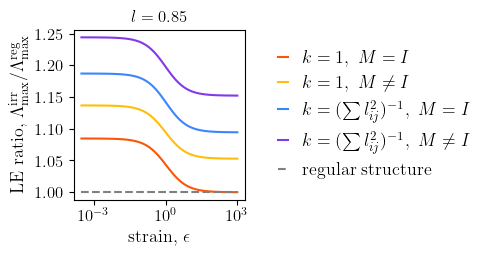

In [10]:
datas = np.load('1D_e_085.npy')
stretches = np.logspace(np.log10(3E-4), np.log10(1E3), 100)
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)
plt.figure(figsize = (my_width, my_width))
#plt.rcParams["font.family"] = "serif"
#plt.rcParams["mathtext.fontset"] = "dejavuserif"
labels = [r'$k=1,\ M \neq I$',
    r'$k=1,\ M = I$',
    
    r'$k=(\sum l_{ij}^2)^{-1},\ M \neq I$',
    r'$k=(\sum l_{ij}^2)^{-1},\ M = I$',
    
]
fontsize_ticks = 12
fontsize_text = 13
order=[1,0,3,2]
for i in range(4):
    plt.semilogx(stretches, np.sqrt(datas[order[i]]),label=labels[order[i]],color=colors[order[i]])
plt.hlines(1.0,xmin=3E-4,xmax=1000,linestyle='--', color='grey',label='regular structure')
plt.xlabel('strain, $\epsilon$',fontsize=fontsize_text)
plt.ylabel('LE ratio, $\Lambda_{\mathrm{max}}^{\mathrm{irr}}/\Lambda_{\mathrm{max}}^\mathrm{{reg}}$',fontsize=fontsize_text)
log_ticks = [1e-3, 1e0,  1e3]

plt.xticks(ticks=log_ticks,fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
#plt.title(f'1D: $N$ = {sz}, $l$ = 0.1', fontname='Arial',fontsize=fontsize_text)
plt.legend(
    frameon=False,
    loc='center left',
    bbox_to_anchor=(1.1, 0.5),
    ncol=1,
    fontsize=fontsize_text,
    handlelength=0.5
)
plt.title('$l=0.85$')
plt.savefig("./GEO_PAPER_FIGS/1D_e085_sq.svg",bbox_inches = "tight",transparent=True)
plt.show()

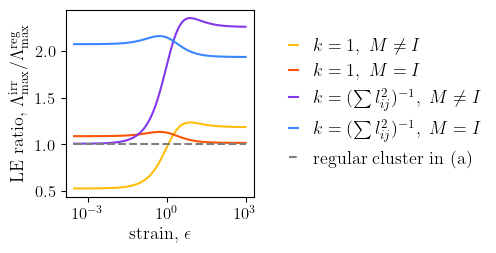

In [8]:
datas = np.load('irrvscluster.npy')
stretches = np.logspace(np.log10(3E-4), np.log10(1E3), 100)
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)
plt.figure(figsize = (my_width*1.1, my_width*1.1))
#plt.rcParams["font.family"] = "serif"
#plt.rcParams["mathtext.fontset"] = "dejavuserif"
labels = [r'$k=1,\ M \neq I$',
    r'$k=1,\ M = I$',
    
    r'$k=(\sum l_{ij}^2)^{-1},\ M \neq I$',
    r'$k=(\sum l_{ij}^2)^{-1},\ M = I$',
    
]
fontsize_ticks = 12
fontsize_text = 13
for i in range(4):
    plt.semilogx(stretches, np.sqrt(datas[i]),label=labels[i],color=colors[i])
plt.hlines(1.0,xmin=3E-4,xmax=1000,linestyle='--', color='grey',label='regular cluster in (a)')
plt.xlabel('strain, $\epsilon$',fontsize=fontsize_text)
plt.ylabel('LE ratio, $\Lambda_{\mathrm{max}}^{\mathrm{irr}}/\Lambda_{\mathrm{max}}^\mathrm{{reg}}$',fontsize=fontsize_text)
plt.xticks(ticks=log_ticks,fontsize=fontsize_ticks)
plt.yticks(fontsize=fontsize_ticks)
#plt.title(f'1D: $N$ = {sz}, $l$ = 0.1', fontname='Arial',fontsize=fontsize_text)
plt.legend(
    frameon=False,
    loc='center left',
    bbox_to_anchor=(1.1, 0.5),
    ncol=1,
    fontsize=fontsize_text,
    handlelength=0.5
)
plt.savefig("./GEO_PAPER_FIGS/2D_irr_sq1.1.svg",bbox_inches = "tight",dpi=300,transparent=True)
plt.show()